In [23]:
import gurobipy as grb
import numpy as np
import timeit
import scipy
from sklearn.datasets import make_classification
import sklearn
from ucimlrepo import fetch_ucirepo 
import math
from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
import copy
from sklearn.utils import shuffle
from sklearn.preprocessing import OneHotEncoder
from collections import Counter
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

In [24]:
def generate_n_sample_vec(y_all, perc_test):
    unique_classes, class_counts = np.unique(y_all, return_counts=True)

    # Compute number of test samples per class
    n_sample = np.floor(class_counts * perc_test).astype(int)

    # Ensure at least 1 test sample for each class 
    for i, count in enumerate(class_counts):
        if n_sample[i] == 0 and count > 0:
            n_sample[i] = 1

    # Compute training samples per class
    n_train_rem = class_counts - n_sample

    n_train = {unique_classes[i]: n_train_rem[i] for i in range(len(unique_classes))}
    n_test = {unique_classes[i]: n_sample[i] for i in range(len(unique_classes))}

    print(f" n_train: {n_train}, n_test: {n_test}")
    return n_train, n_test


def l2_normalize_rows(X, eps=1e-12):

    X = np.asarray(X, dtype=float)
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    return X / np.maximum(norms, eps)


def class_split_per_client(train_class_counts, perc_class_per_client, G, client_sample_props):
    
    n_classes = len(train_class_counts)
    
    #Case 1: User-defined table of percentages per client and per class
    if isinstance(perc_class_per_client, np.ndarray):
        print("Using user-defined percentages")
        if perc_class_per_client.shape != (G, n_classes):
            raise ValueError(f"The shape of `perc_class_per_client` should be ({G}, {n_classes})")

        row_sums = perc_class_per_client.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1 
        perc_class_per_client = perc_class_per_client / row_sums
        
        use_client_sample_props = True
        if client_sample_props is None:
            client_sample_props = [1 / G] * G
        
    # Case 2: Randomly generated percentages for each client
    elif perc_class_per_client == -1:
        
        if G == 1:
            perc_class_per_client = {0: {class_label: 1.0 for class_label in train_class_counts}}  
        
        else:
            if G == 2:
                perc_class_per_client = {}
                for class_label in train_class_counts:
                    r = np.random.uniform(low=0.1, high=0.9)
                    perc_class_per_client[0] = perc_class_per_client.get(0, {})
                    perc_class_per_client[0][class_label] = r
                    perc_class_per_client[1] = perc_class_per_client.get(1, {})
                    perc_class_per_client[1][class_label] = 1 - r
                
            else:
                perc_class_per_client = {g: {class_label: 0 for class_label in train_class_counts.keys()} for g in range(G)}
                for class_label in train_class_counts:
                    remaining = 1.0
                    for g in range(G - 1):
                        min_allowed = 0.1
                        max_allowed = remaining - min_allowed * (G - g - 1)
                        r = np.random.uniform(low=min_allowed, high=max_allowed)
                        perc_class_per_client[g] = perc_class_per_client.get(g, {})
                        perc_class_per_client[g][class_label] = r
                        remaining -= r
                    perc_class_per_client[G - 1][class_label] = remaining
                    
    # Case 3: Uniform distribution across clients
    elif perc_class_per_client == 0:
        perc_class_per_client = {g: {class_label: 1/G for class_label in train_class_counts} for g in range(G)}
        
        use_client_sample_props = False
    else:
        use_client_sample_props = True
        
    print(f"Per class per client:{perc_class_per_client}")
    
    class_split = {g: {} for g in range(G)}  

    for class_label, total_available in train_class_counts.items():  
        print(f"Class {class_label}: Total available samples: {total_available}")
        
        if use_client_sample_props and client_sample_props is not None:
            allocations = [
                int(np.floor(
                    total_available *
                    client_sample_props[g] *
                    perc_class_per_client[g].get(class_label, 0)
                ))
                for g in range(G)
            ]
        else:
            allocations = [
                int(np.floor(
                    total_available *
                    perc_class_per_client[g].get(class_label, 0)
                ))
                for g in range(G)
            ]
        
        total_allocated = sum(allocations)
        discrepancy = total_available - total_allocated
        
        print(f"Class {class_label}: Preliminary allocations: {allocations}")
        print(f"Class {class_label}: Total allocated after floor: {total_allocated}")
        print(f"Class {class_label}: Discrepancy: {discrepancy}")
        
        
        # Distribute the discrepancy
        for g in range(G):
            if discrepancy > 0:
                allocations[g] += 1  
                discrepancy -= 1 
                
        if total_available < G:
            # Distribute the available samples evenly among clients
            for g in range(total_available):  # Distribute one sample to each client until samples run out
                allocations[g] = 1  # Assign one sample to each of the available clients

            # Set remaining clients to 0 if there are fewer samples than clients
            for g in range(total_available, G):
                allocations[g] = 0 
                
        print(f"Class {class_label}: Final allocations per client: {allocations}")   
        
        for g in range(G):
            class_split[g][class_label] = allocations[g] 
         
        
    print(f"Class Split:{class_split}")
        
    return class_split

def change_labels(perc_wrong_y, total_samples, num_classes, y, seed=None):
    y = y.copy()
    rng = np.random.default_rng(seed) 

    n_wrong = int(round(perc_wrong_y * total_samples))
    if n_wrong == 0:
        return y

    idx_wrong = rng.choice(total_samples, size=n_wrong, replace=False)

    for i in idx_wrong:
        old = int(y[i])
        new = rng.integers(0, num_classes - 1)
        if new >= old:
            new += 1
        y[i] = new

    return y

In [25]:
class MultiFederatedDRSVM:
    def __init__(self, param, num_clients, num_classes, feature_dim):
        self.epsilon = param['epsilon']
        self.kappa = param['kappa']
        self.pnorm = param['pnorm']
        self.rho = param['rho']  
        self.tau = param['tau'] 
        self.num_clients = num_clients
        self.num_classes = num_classes
        self.feature_dim = feature_dim
        self.alphag_vec = np.ones(self.num_clients)  
        self.Ng_vec = np.zeros(self.num_clients)
        
        self.local_models = [{} for _ in range(num_clients)]
        self.global_model = np.zeros((num_classes, self.feature_dim))  # Weight matrix M: Rows (Classes) * Columns (features)
        #List of mu matrices, one per client
        self.mu = [np.zeros((num_classes, self.feature_dim)) for _ in range(num_clients)] #ADMM dual for each client g: Rows (Classes) * Columns (features)
        
        
    def local_update(self, client_id, x_train, y_train, M_global, mu):

        row, col = x_train.shape
        optimal = {}
        
        encoder = OneHotEncoder(sparse=False)
        y_train_one_hot = encoder.fit_transform(y_train.reshape(-1, 1))
        
        
        # Step 0: Create model
        model = grb.Model(f'DRSVM_Client_{client_id}')
        model.setParam('OutputFlag', False)

        #Step 1: Define decision variables
        var_lambda = model.addVar(vtype=grb.GRB.CONTINUOUS, lb=0.0, name="lambda")
        var_s = var_s = {i: model.addVar(vtype=grb.GRB.CONTINUOUS, lb=0.0, name=f"s[{i}]") for i in range(row)} #Slack variable for each training sample
        
        #Decision variable (Matrix) that holds the weight for class c and feature j
        var_M = {(c, j): model.addVar(vtype=grb.GRB.CONTINUOUS, lb=-grb.GRB.INFINITY)
         for c in range(self.num_classes) for j in range(col)}
        
        # L1 norm constraint
        if self.pnorm == 1:
            slack_var = {(i, j, p): model.addVar(vtype=grb.GRB.CONTINUOUS)
                         for i in range(self.num_classes) 
                         for j in range(self.num_classes) 
                         for p in range(col)}

            
        #Step 2: Integrate variables
        model.update()
        
        #Step 3: Define constraints
        for i in range(len(y_train_one_hot)):
            true_class = np.argmax(y_train_one_hot[i])  
            
            # Iterate over all classes
            for c in range(self.num_classes):
                if c != true_class:  # c is wrong label 

                    # score of the observed label
                    margin_y = grb.quicksum(var_M[(true_class, j)] * x_train[i, j] for j in range(col))

                    # score of label c
                    margin_c = grb.quicksum(var_M[(c, j)] * x_train[i, j] for j in range(col))

                    # CS loss at the observed label true_class 
                    model.addConstr(margin_c - margin_y + 1 <= var_s[i])

                    # CS loss at the label c
                    for j_cls in range(self.num_classes):
                        if j_cls == c:
                            continue

                        margin_j = grb.quicksum(var_M[(j_cls, j)] * x_train[i, j] for j in range(col))
                        model.addConstr(margin_j - margin_c + 1 - self.kappa * var_lambda <= var_s[i])

                    
            
        if self.pnorm == 1:
            for i in range(self.num_classes):
                for j in range(self.num_classes):
                    if i != j:
                        for p in range(col):
                            model.addConstr(var_M[(i, p)] - var_M[(j, p)] <= slack_var[(i, j, p)])
                            model.addConstr(-(var_M[(i, p)] - var_M[(j, p)]) <= slack_var[(i, j, p)])

                        
                        model.addConstr(
                            grb.quicksum(slack_var[(i, j, p)] for p in range(col)) <= var_lambda
                        )


        elif self.pnorm == 2:
            for i in range(self.num_classes):
                for j in range(self.num_classes):
                    if i != j:
                        model.addQConstr(
                            grb.quicksum((var_M[(i, p)] - var_M[(j, p)]) * (var_M[(i, p)] - var_M[(j, p)])
                                         for p in range(col))
                            <= var_lambda * var_lambda
                        )


        elif self.pnorm == float('Inf'):
            for i in range(self.num_classes):
                for j in range(i + 1, self.num_classes):
                    for p in range(col):
                        model.addConstr(var_M[(i, p)] - var_M[(j, p)] <= var_lambda)
                        model.addConstr(-(var_M[(i, p)] - var_M[(j, p)]) <= var_lambda)

        #Step 4: Define objective value
        sum_var_s = grb.quicksum(var_s[i] for i in range(row))
        norm_regularizer = grb.quicksum(
            (var_M[(c, j)] - self.global_model[c, j] + mu[c, j]) * 
            (var_M[(c, j)] - self.global_model[c, j] + mu[c, j])
            for c in range(self.num_classes)
            for j in range(col)
        ) 
        convergence_regularizer = self.tau * grb.quicksum(
            var_M[(c, j)] * var_M[(c, j)]
            for c in range(self.num_classes)
            for j in range(col)
        ) 
        obj = (var_lambda * self.epsilon  
               + ((1 / row) * sum_var_s)  
               + ((self.rho / 2) * norm_regularizer) + convergence_regularizer)

        
        model.setObjective(obj, grb.GRB.MINIMIZE)
        model.optimize()
        
        # Step 6: Store results for the multiclass case
        w_opt = np.zeros((self.num_classes, col))
   
        for c in range(self.num_classes):
            for j in range(col):
                w_opt[c, j] = var_M[(c, j)].x

        tmp = {'w': w_opt, 'objective': model.ObjVal, 'diagnosis': model.status}
        optimal.update(tmp)

        return optimal
    
    def train(self, client_sets, num_rounds):
       
        self.Ng_vec = np.array([len(client_sets['x' + str(i)]) for i in range(self.num_clients)])

        prev_global_model = np.copy(self.global_model)
        
        for num_round in range(num_rounds):
            local_models = [] #Store local weights for each client
            
            for i in range(self.num_clients):
                
                x_train = client_sets['x' + str(i)]
                y_train = client_sets['y' + str(i)]
                
                #Solve each clients local problem
                local_M = self.local_update(i, x_train, y_train, self.global_model, self.mu[i])
                #Store clients M_g
                local_models.append(local_M)
            
            self.alphag_vec = self.Ng_vec / np.sum(self.Ng_vec)
            
            local_updates = np.array([local_models[i]['w'] + self.mu[i] for i in range(self.num_clients)])

            weighted_updates = self.alphag_vec[:, np.newaxis, np.newaxis] * local_updates  

            self.global_model = np.sum(weighted_updates, axis=0)  

            diff_weights = np.linalg.norm(self.global_model - prev_global_model)
            print(f"Weight change norm (round {num_round}):", diff_weights)
            
            prev_global_model = np.copy(self.global_model)
            
            for i in range(self.num_clients):
                self.mu[i] += local_models[i]['w'] - self.global_model  
        

        return self.global_model


    def test(self, client_sets_norm):
        """Test the model with provided data (N samples, P features)"""

        x_test = client_sets_norm['x']
        row_x, col_x = x_test.shape
        C = self.global_model.shape[0]  # Number of classes
        y_pred = np.zeros((row_x, C), dtype=int)  # One-hot encoded output

        w_global = self.global_model  # Access the trained weights from the model

        for n in range(row_x):
            # Compute the linear output for each sample
            linear_output = np.matmul(w_global, x_test[n])
            
            # Get the class with the maximum score
            class_index = np.argmax(linear_output)
            
            y_pred[n, class_index] = 1


        return y_pred

In [26]:
class MultiFederatedPrivateDRSVM_Linearized:

    def __init__(self, param, num_clients, num_classes):
        # DRO + ADMM params
        self.epsilon = float(param["epsilon"])
        self.kappa   = float(param["kappa"])
        self.pnorm   = param["pnorm"]   
        self.rho     = float(param["rho"])
        # Bertsekas penalty parameters
        self.gamma_pen = float(param.get("gamma_pen", 1.0))   
        self.tau_init  = float(param.get("tau_init", 0.0))    
        self.nu      = param.get("nu", None)  

        self.num_clients = int(num_clients)
        self.num_classes = int(num_classes)

        # DP params (optional)
        self.dp_on    = bool(param.get("dp_on", False))
        self.eps_dp   = param.get("eps_dp", None)
        self.delta_dp = param.get("delta_dp", None)
        self.cw       = float(param.get("cw", 1.0))
        self.L = float(param.get("L", 1.0))   # loss M-block bound
        self.C = float(param.get("C", 1.0))   # penalty M-block bound

        self.feature_dim  = None
        self.Ng_vec       = None
        self.alphag_vec   = None

        self.global_model = None               
        self.mu           = None              

        self.M_prev       = None               
        self.lam_prev     = None               
        self.tau_prev = None
        
        self.clambda = float(param.get("clambda", 1.0))
        self.S_lam = float(param.get("S_lam", 1.0))
        self.V_lam = float(param.get("V_lam", 1.0))

    # DP step sizes
    def eta_gk(self, g, k):
        Ng = float(self.Ng_vec[g])
        d  = int(self.feature_dim)
        K  = int(self.num_classes)
        dp = d * K

        term = (
            2.0 * (self.L + self.C)**2
            + dp * (8.0 * self.L**2 / (Ng**2)) * (2.0 * np.log(1.25 / self.delta_dp) / (self.eps_dp**2))
        )
        return self.cw / np.sqrt(2.0 * k * term)

    def nu_gk(self, k: int) -> float:

        c_lam = float(self.clambda if self.clambda is not None else 1.0)
        denom = np.sqrt(2.0 * k) * (self.S_lam + self.V_lam)
        if c_lam <= 0:
            raise ValueError("clambda must be > 0")
        if denom <= 0:
            raise ValueError("Need S_lam + V_lam > 0 to define nu_gk")
        return c_lam / denom
    

    def sigma_gk(self, g, k):
        Ng  = float(self.Ng_vec[g])
        eta = self.eta_gk(g, k)
        return ((2.0*np.sqrt(2.0)*self.L) / (Ng*(self.rho + 1.0/eta))
                * np.sqrt(2.0*np.log(1.25/self.delta_dp)) / self.eps_dp)
    
    # Past iteration function evaluation 
    def _cs_hinge_value(self, scores, y):

        tmp = scores.copy()
        tmp[y] = -np.inf
        c_star = int(np.argmax(tmp))
        H = 1.0 + scores[c_star] - scores[y]
        return float(max(0.0, H))


    def phi_value(self, M):

        K, d = M.shape
        best_val = -np.inf

        for i in range(K):
            for j in range(K):
                if i == j:
                    continue
                u = M[i, :] - M[j, :]

                if self.pnorm == 1:
                    val = np.sum(np.abs(u))              # ||u||_1
                elif self.pnorm == 2:
                    val = np.linalg.norm(u, 2)           # ||u||_2
                elif self.pnorm == np.inf or self.pnorm == float('Inf'):
                    val = np.max(np.abs(u))              # ||u||_inf
                else:
                    raise ValueError("Use pnorm=1, 2, or np.inf.")

                if val > best_val:
                    best_val = val

        return float(best_val)


    def bertsekas_penalty_value(self, M, lam, gamma_pen, tau):

        phi = self.phi_value(M)
        r = float(tau + gamma_pen * (phi - lam))
        return (max(0.0, r)**2 - float(tau)**2) / (2.0 * float(gamma_pen))


    def f_value(self, M, lam, x_train, y_train, gamma_pen, tau):

        K = self.num_classes
        N, d = x_train.shape
        if N == 0:
            return 0.0

        y_train = y_train.astype(int)
        total = 0.0

        for n in range(N):
            x = x_train[n]
            y_true = int(y_train[n])
            scores = M @ x

            A = self._cs_hinge_value(scores, y_true)

            B_best = -np.inf
            for y in range(K):
                if y == y_true:
                    continue
                loss_y = self._cs_hinge_value(scores, y)
                val = loss_y - self.kappa * lam
                if val > B_best:
                    B_best = val

            total += max(A, B_best)

        loss_part = total / float(N)
        pen_part = self.bertsekas_penalty_value(M, lam, gamma_pen, tau)

        return float(loss_part + pen_part)

    
    # compute largest dual between any two class weights
    def phi_and_subgrad(self, M):

        K, d = M.shape
        best_val = -np.inf
        best_i = best_j = None
        best_u = None

        for i in range(K):
            for j in range(K):
                if i == j:
                    continue

                u = M[i, :] - M[j, :]

                if self.pnorm == 1:
                    val = np.sum(np.abs(u))
                elif self.pnorm == 2:
                    val = np.linalg.norm(u, 2)
                elif self.pnorm == np.inf or self.pnorm == float("Inf"):
                    val = np.max(np.abs(u))
                else:
                    raise ValueError("Use pnorm=1, 2, or np.inf.")

                if val > best_val:
                    best_val = val
                    best_i, best_j = i, j
                    best_u = u.copy()

        phi = float(best_val)
        Gphi = np.zeros_like(M)

        if best_u is None:
            return 0.0, Gphi

        if self.pnorm == 1:
            
            g = np.sign(best_u)   

        elif self.pnorm == 2:
            norm_u = np.linalg.norm(best_u, 2)
            if norm_u > 1e-12:
                g = best_u / norm_u
            else:
                g = np.zeros(d)

        else:  
            p_star = int(np.argmax(np.abs(best_u)))
            g = np.zeros(d)
            if abs(best_u[p_star]) > 1e-12:
                g[p_star] = np.sign(best_u[p_star])
            else:
                g[p_star] = 0.0

        Gphi[best_i, :] += g
        Gphi[best_j, :] -= g

        return phi, Gphi

    #  subgradient at previous iterate 
    def _cs_hinge_and_grad(self, scores, x, y):

        K = scores.shape[0]
        # best competitor class 
        tmp = scores.copy()
        tmp[y] = -np.inf
        c_star = int(np.argmax(tmp))

        H = 1.0 + scores[c_star] - scores[y]
        if H <= 0.0:
            return 0.0, None  

        # subgrad wrt M
        return float(H), (c_star, y)  


    def subgrad_f(self, M_prev, lam_prev, x_train, y_train, gamma_pen, tau):

        K = self.num_classes
        N, d = x_train.shape
        if N == 0:
            return np.zeros((K, d), dtype=float), 0.0

        y_train = y_train.astype(int)

        G_M = np.zeros((K, d), dtype=float)
        g_lam = 0.0

        # loss part
        for n in range(N):
            x = x_train[n]
            y_true = int(y_train[n])

            scores = M_prev @ x  
            
            A_loss, A_pair = self._cs_hinge_and_grad(scores, x, y_true)

            B_best = -np.inf
            B_loss = 0.0
            B_pair = None

            for y in range(K):
                if y == y_true:
                    continue
                loss_y, pair_y = self._cs_hinge_and_grad(scores, x, y)
                val = loss_y - self.kappa * lam_prev
                if val > B_best:
                    B_best = val
                    B_loss = loss_y
                    B_pair = pair_y

            # outer max
            if A_loss >= B_best:
                # choose A branch
                if A_pair is not None:
                    c_star, y = A_pair
                    G_M[c_star, :] += x
                    G_M[y,      :] -= x
                # no lambda term from A
            else:
                # choose B branch
                if B_pair is not None:
                    c_star, y = B_pair
                    G_M[c_star, :] += x
                    G_M[y,      :] -= x
                # lambda derivative
                g_lam += -self.kappa

        # average loss subgrad 
        G_M /= float(N)
        g_lam /= float(N)

        # Bertsekas penalty part 
        phi_val, G_phi = self.phi_and_subgrad(M_prev)
        r = float(tau + gamma_pen * (phi_val - lam_prev))
        if r > 0.0:
            G_M += r * G_phi
            g_lam += -r
        #returns subgradient wrt M and wrt lambda    
        return G_M, g_lam


    #  linearized local QP solve 
    def local_update_linearized(self, client_id, x_train, y_train, M_global, mu, k):

        N, d = x_train.shape
        K = self.num_classes
        

        M_prev  = self.M_prev[client_id]
        lam_prev = float(self.lam_prev[client_id])

        if self.dp_on:
            eta = self.eta_gk(client_id, k)
        else:
            eta = self.cw / np.sqrt(2.0 * max(k, 1))

        if self.nu is None:
            nu = self.nu_gk(k)
        else:
            nu = float(self.nu)

        tau = float(self.tau_prev[client_id])
        gamma_pen = float(self.gamma_pen)

        G_M, g_lam = self.subgrad_f(
            M_prev, lam_prev, x_train, y_train,
            gamma_pen=gamma_pen, tau=tau
        )

        f_prev = self.f_value(
            M_prev, lam_prev, x_train, y_train,
            gamma_pen=gamma_pen, tau=tau
        )

        model = grb.Model(f"LIN_DRSVM_Client_{client_id}")
        model.setParam("OutputFlag", False)

        var_lambda = model.addVar(vtype=grb.GRB.CONTINUOUS, lb=0.0)
        var_M = {(c, j): model.addVar(vtype=grb.GRB.CONTINUOUS, lb=-grb.GRB.INFINITY)
                 for c in range(K) for j in range(d)}

        model.update()

        # Objective
        obj = 0.0

        # lambda * epsilon
        obj += var_lambda * self.epsilon

        # <G_M, M - M_prev>
        obj += grb.quicksum(
            float(G_M[c, j]) * (var_M[(c, j)] - float(M_prev[c, j]))
            for c in range(K) for j in range(d)
        )

        # g_lam * (lambda - lam_prev)
        obj += float(g_lam) * (var_lambda - float(lam_prev))

        # rho/2 ||M - M_global + mu||^2
        obj += (self.rho / 2.0) * grb.quicksum(
            (var_M[(c, j)] - float(M_global[c, j]) + float(mu[c, j]))
            * (var_M[(c, j)] - float(M_global[c, j]) + float(mu[c, j]))
            for c in range(K) for j in range(d)
        )

        # 1/(2 eta) ||M - M_prev||^2
        obj += (1.0 / (2.0 * eta)) * grb.quicksum(
            (var_M[(c, j)] - float(M_prev[c, j])) * (var_M[(c, j)] - float(M_prev[c, j]))
            for c in range(K) for j in range(d)
        )

        # 1/(2 nu) (lambda - lam_prev)^2
        obj += (1.0 / (2.0 * nu)) * (var_lambda - float(lam_prev)) * (var_lambda - float(lam_prev))
        

        model.setObjective(obj, grb.GRB.MINIMIZE)
        model.optimize()

        status = model.Status
        print(f"[client {client_id}, round {k}] status = {status}")

        if status != grb.GRB.OPTIMAL:
            print(f"[client {client_id}, round {k}] non-optimal solve")
            print(f"  eta = {eta}")
            print(f"  nu = {nu}")
            print(f"  tau = {tau}")
            print(f"  gamma_pen = {gamma_pen}")
            print(f"  lam_prev = {lam_prev}")
            print(f"  g_lam = {g_lam}")
            print(f"  f_prev = {f_prev}")
            print(f"  any NaN in G_M? {np.isnan(G_M).any()}")
            print(f"  any Inf in G_M? {np.isinf(G_M).any()}")
            print(f"  any NaN in M_prev? {np.isnan(M_prev).any()}")
            print(f"  any Inf in M_prev? {np.isinf(M_prev).any()}")

            return {
                "w": M_prev.copy(),
                "lambda": float(lam_prev),
                "objective_qp": np.nan,
                "f_prev": float(f_prev),
                "Lhat": np.nan,
                "status": int(status),
                "eta_used": float(eta),
            }

        obj_val = float(model.ObjVal)
        Lhat = float(f_prev + obj_val)

        w_opt = np.zeros((K, d), dtype=float)
        for c in range(K):
            for j in range(d):
                w_opt[c, j] = var_M[(c, j)].X

        return {
            "w": w_opt,
            "lambda": float(var_lambda.X),
            "objective_qp": obj_val,
            "f_prev": float(f_prev),
            "Lhat": Lhat,
            "status": int(status),
            "eta_used": float(eta),
        }

    #  training loop 
    def train(self, client_sets, num_rounds):
        # sizes
        self.Ng_vec = np.array([len(client_sets[f"x{i}"]) for i in range(self.num_clients)], dtype=float)
        self.alphag_vec = self.Ng_vec / np.sum(self.Ng_vec)

        # init dims + vars
        if self.feature_dim is None:
            self.feature_dim = int(client_sets["x0"].shape[1])

        K, d = self.num_classes, self.feature_dim

        if self.global_model is None:
            self.global_model = np.zeros((K, d), dtype=float)
        if self.mu is None:
            self.mu = [np.zeros((K, d), dtype=float) for _ in range(self.num_clients)]

        if self.M_prev is None:
            self.M_prev = [np.zeros((K, d), dtype=float) for _ in range(self.num_clients)]
        if self.lam_prev is None:
            self.lam_prev = [0.0 for _ in range(self.num_clients)]
        if self.tau_prev is None:
            self.tau_prev = [float(self.tau_init) for _ in range(self.num_clients)]

        # L setup 
        if self.dp_on:
            if self.L is None:
                self.L = 1
            if self.eps_dp is None or self.delta_dp is None:
                raise ValueError("dp_on=True requires eps_dp and delta_dp")
            if self.eps_dp <= 0:
                raise ValueError("eps_dp must be > 0")
            if not (0 < self.delta_dp < 1):
                raise ValueError("delta_dp must be in (0,1)")

        prev_global = self.global_model.copy()

        for k in range(1, int(num_rounds) + 1):
            local_models = []

            for i in range(self.num_clients):
                x_i = client_sets[f"x{i}"]
                y_i = client_sets[f"y{i}"].astype(int)

                out = self.local_update_linearized(
                    client_id=i,
                    x_train=x_i,
                    y_train=y_i,
                    M_global=self.global_model,
                    mu=self.mu[i],
                    k=k
                )

                w_clean = out["w"]
                lam_clean = out["lambda"]

                
                self.M_prev[i] = w_clean.copy()
                self.lam_prev[i] = float(lam_clean)
                
                #  alpha update 
                phi_val, _ = self.phi_and_subgrad(w_clean)
                gamma_pen = float(self.gamma_pen)
                self.tau_prev[i] = max(0.0, self.tau_prev[i] + gamma_pen * (phi_val - lam_clean))
                
                # DP noise
                if self.dp_on:
                    sigma = self.sigma_gk(i, k)
                    noise = np.random.normal(0.0, sigma, size=w_clean.shape)
                    w_send = w_clean + noise
                else:
                    w_send = w_clean

                out["w_clean"] = w_clean
                out["w_send"] = w_send
                local_models.append(out)

            
            local_updates = np.array([local_models[i]["w_send"] + self.mu[i] for i in range(self.num_clients)])
            weighted = self.alphag_vec[:, None, None] * local_updates
            self.global_model = np.sum(weighted, axis=0)

            # dual update
            for i in range(self.num_clients):
                self.mu[i] += local_models[i]["w_send"] - self.global_model

            diff = np.linalg.norm(self.global_model - prev_global)
            print(f"[LIN-DRO] round {k}: ||w^k - w^{k-1}||_F = {diff:.4e}")
            prev_global = self.global_model.copy()

        return self.global_model

    # ---------------- prediction ----------------
    def test(self, test_set):
        x_test = test_set["x"]
        scores = x_test @ self.global_model.T
        y_hat = np.argmax(scores, axis=1)
        
        counts = np.bincount(y_hat, minlength=self.num_classes)
        print("Pred counts:", counts)

        N = x_test.shape[0]
        K = self.num_classes
        y_pred = np.zeros((N, K), dtype=int)
        y_pred[np.arange(N), y_hat] = 1
        return y_pred

In [27]:
class MultiFederatedERMSVM_DP_ADMM:


    def __init__(self, param, num_clients, num_classes):
        self.num_clients = num_clients
        self.num_classes = num_classes

        # ADMM / ERM params
        self.rho = param.get("rho", 1.0)
        self.lambda_reg = param.get("lambda_reg", 1e-2)  

        self.dp_on    = param.get("dp_on", False)
        self.eps_dp   = param.get("eps_dp", None)
        self.delta_dp = param.get("delta_dp", None)
        self.cw       = param.get("cw", 1.0)
        self.L        = param.get("L", None)  

        self.feature_dim = None
        self.Ng_vec = None

        self.global_model = None            
        self.w_tilde_prev = None            
        self.gamma = None                   



    #  DP step sizes
    def eta_gk(self, i, k):
        Ng = self.Ng_vec[i]
        d  = self.feature_dim
        p  = self.num_classes
        dp = d * p

        term = self.L**2 + dp * (4*self.L**2/(Ng**2)) * (2*np.log(1.25/self.delta_dp)/(self.eps_dp**2))
        return self.cw / np.sqrt(2.0 * k * term)

    def sigma_gk(self, i, k):
        Ng = self.Ng_vec[i]
        eta = self.eta_gk(i, k)
        return (2.0*np.sqrt(2.0)*self.L)/(Ng*(self.rho + 1.0/eta)) * np.sqrt(2.0*np.log(1.25/self.delta_dp))/self.eps_dp

    #  ERM loss subgradient at M_prev 
    def subgrad_multiclass_hinge(self, M_prev, x, y):

        K, d = M_prev.shape
        scores = M_prev @ x
        y = int(y)

        tmp = scores.copy()
        tmp[y] = -np.inf
        c_star = int(np.argmax(tmp))

        margin = 1.0 + scores[c_star] - scores[y]
        if margin <= 0.0:
            return np.zeros((K, d), dtype=float)

        G = np.zeros((K, d), dtype=float)
        G[c_star, :] += x
        G[y,      :] -= x
        return G

    def grad_f_i(self, i, x_i, y_i, M_prev):

        mi = x_i.shape[0]
        K, d = M_prev.shape

        if mi == 0:
            return np.zeros((K, d), dtype=float)

        G = np.zeros((K, d), dtype=float)
        for j in range(mi):
            G += self.subgrad_multiclass_hinge(M_prev, x_i[j], y_i[j])
        G /= float(mi)

        # regularizer
        G += (self.lambda_reg / float(self.num_clients)) * M_prev
        return G

    # closed-form solution of the prox-linearized subproblem
    def local_step_closed_form(self, i, k, x_i, y_i):

        w_prev = self.global_model
        wtilde_prev = self.w_tilde_prev[i]
        gamma_prev = self.gamma[i]

        eta = self.eta_gk(i, k)
        g = self.grad_f_i(i, x_i, y_i, wtilde_prev)

        denom = (self.rho + 1.0/eta)
        w_clean = (self.rho * w_prev + (1.0/eta) * wtilde_prev + gamma_prev - g) / denom
        return w_clean

    def train(self, client_sets, num_rounds):
        
        self.feature_dim = client_sets["x0"].shape[1]
        K, d = self.num_classes, self.feature_dim

        self.Ng_vec = np.array([len(client_sets[f"x{i}"]) for i in range(self.num_clients)])

        if self.L is None:
            self.L = np.sqrt(self.feature_dim)

        # DP 
        if self.dp_on:
            if self.eps_dp is None or self.delta_dp is None:
                raise ValueError("dp_on=True requires eps_dp and delta_dp")
            if self.eps_dp <= 0:
                raise ValueError("eps_dp must be > 0")
            if not (0 < self.delta_dp < 1):
                raise ValueError("delta_dp must be in (0,1)")

        if self.global_model is None:
            self.global_model = np.zeros((K, d), dtype=float)         
        if self.gamma is None:
            self.gamma = [np.zeros((K, d), dtype=float) for _ in range(self.num_clients)]  
        if self.w_tilde_prev is None:
            self.w_tilde_prev = [np.zeros((K, d), dtype=float) for _ in range(self.num_clients)] 

        for k in range(1, num_rounds + 1):
            w_clean_list = []
            w_tilde_list = []

            for i in range(self.num_clients):
                x_i = client_sets[f"x{i}"]
                y_i = client_sets[f"y{i}"].astype(int)

                w_clean = self.local_step_closed_form(i, k, x_i, y_i)

                if self.dp_on:
                    sigma = self.sigma_gk(i, k)
                    noise = np.random.normal(0.0, sigma, size=w_clean.shape)
                    w_tilde = w_clean + noise
                else:
                    w_tilde = w_clean

                w_clean_list.append(w_clean)
                w_tilde_list.append(w_tilde)

            # server update
            w_tilde_bar = np.mean(np.array(w_tilde_list), axis=0)
            gamma_bar = np.mean(np.array(self.gamma), axis=0)

            self.global_model = w_tilde_bar - (gamma_bar / self.rho)

            # dual update
            for i in range(self.num_clients):
                self.gamma[i] = self.gamma[i] - self.rho * (w_tilde_list[i] - self.global_model)
                self.w_tilde_prev[i] = w_tilde_list[i].copy()

        return self.global_model

    def test(self, test_set):
        x_test = test_set["x"]
        scores = x_test @ self.global_model.T
        y_hat = np.argmax(scores, axis=1)

        N = x_test.shape[0]
        K = self.num_classes
        y_pred = np.zeros((N, K), dtype=int)
        y_pred[np.arange(N), y_hat] = 1
        return y_pred

In [30]:
def mCCR(y_true, y_pred, num_classes=None):
    if num_classes is None:
        num_classes = int(max(np.max(y_true), np.max(y_pred))) + 1

    per_class_acc = np.zeros(num_classes)

    for c in range(num_classes):
        mask = (y_true == c)
        denom = np.sum(mask)

        if denom > 0:
            per_class_acc[c] = np.mean(y_pred[mask] == c)
        else:
            per_class_acc[c] = np.nan

    return np.nanmean(per_class_acc)

In [31]:
def evaluate_mccr(model, test_set, num_classes, verbose=True):
    x_test = test_set["x"]
    y_true = test_set["y"].astype(int)

    y_pred_onehot = model.test(test_set)
    y_pred = np.argmax(y_pred_onehot, axis=1)

    acc = accuracy_score(y_true, y_pred)
    mccr_val = mCCR(y_true, y_pred, num_classes=num_classes)

    if verbose:
        print(f"accuracy={acc:.3f}, mCCR={mccr_val:.3f}")

    return mccr_val


In [32]:
def run_privacy_utility_experiment(
    eps_list,
    seeds,
    num_classes,
    train_dp_erm,   
    train_dp_dro,  
    train_np_dro    
):
    results = {
        "eps": [],
        "dp_erm_mean": [], "dp_erm_std": [],
        "dp_dro_mean": [], "dp_dro_std": [],
        "np_dro_mean": [], "np_dro_std": []
    }


    np_scores_by_seed = {}

    for seed in seeds:
        model_np, test_set_np = train_np_dro(seed)
        np_score = evaluate_mccr(model_np, test_set_np, num_classes, verbose=True)
        np_scores_by_seed[seed] = np_score

    fixed_np_scores = [np_scores_by_seed[seed] for seed in seeds]
    fixed_np_mean = float(np.mean(fixed_np_scores))
    fixed_np_std = float(np.std(fixed_np_scores, ddof=1)) if len(fixed_np_scores) > 1 else 0.0


    for eps_dp in eps_list:
        erm_scores = []
        dro_scores = []

        for seed in seeds:
            #  DP ERM 
            model_erm, test_set_erm = train_dp_erm(eps_dp, seed)
            erm_scores.append(evaluate_mccr(model_erm, test_set_erm, num_classes))

            # DP DRO 
            model_dro, test_set_dro = train_dp_dro(eps_dp, seed)
            dro_scores.append(evaluate_mccr(model_dro, test_set_dro, num_classes))

        results["eps"].append(eps_dp)

        results["dp_erm_mean"].append(float(np.mean(erm_scores)))
        results["dp_erm_std"].append(float(np.std(erm_scores, ddof=1)) if len(erm_scores) > 1 else 0.0)

        results["dp_dro_mean"].append(float(np.mean(dro_scores)))
        results["dp_dro_std"].append(float(np.std(dro_scores, ddof=1)) if len(dro_scores) > 1 else 0.0)

        results["np_dro_mean"].append(fixed_np_mean)
        results["np_dro_std"].append(fixed_np_std)

        print(
            f"eps={eps_dp}: "
            f"DP-ERM mCCR={results['dp_erm_mean'][-1]:.3f}, "
            f"DP-DRO mCCR={results['dp_dro_mean'][-1]:.3f}, "
            f"NP-DRO mCCR={results['np_dro_mean'][-1]:.3f}"
        )

    return results

In [33]:
def plot_privacy_utility(results):
    eps = np.array(results["eps"], dtype=float)

    colors = {
        "erm": "#4C78A8",
        "dro": "#C44E52",
    }

    fig, ax = plt.subplots(figsize=(6.4, 4.2))

    ax.errorbar(
        eps, results["dp_erm_mean"], yerr=results["dp_erm_std"],
        fmt='-', linewidth=1.9, elinewidth=1.2,
        capsize=4, capthick=1.2,
        color=colors["erm"], label="DP-Fed ERM "
    )

    ax.errorbar(
        eps, results["dp_dro_mean"], yerr=results["dp_dro_std"],
        fmt='-', linewidth=1.9, elinewidth=1.2,
        capsize=4, capthick=1.2,
        color=colors["dro"], label="DP-Fed DRO"
    )

    ax.errorbar(
        eps, results["np_dro_mean"], yerr=results["np_dro_std"],
        fmt='--', linewidth=1.8, elinewidth=1.0,
        capsize=4, capthick=1.0,
        color="black", label="Non-Private Fed DRO"
    )

    ax.set_xscale("linear")
    ax.set_xticks(eps)
    ax.set_xticklabels([f"{x:g}" for x in eps])

    span = eps.max() - eps.min()
    if span == 0:
        span = 1.0
    ax.set_xlim(eps.min() - 0.08 * span, eps.max() + 0.08 * span)

    # fixed y-axis across all plots
    ax.set_ylim(0.3, 0.9)

    ax.grid(True, which="major", linestyle=":", linewidth=0.6, alpha=0.35)
    ax.grid(False, which="minor")

    for s in ["top", "right", "left", "bottom"]:
        ax.spines[s].set_visible(True)
        ax.spines[s].set_linewidth(1.0)

    ax.set_xlabel(r"$\epsilon$", fontsize=16, fontfamily="serif")
    ax.set_ylabel("mCCR", fontsize=16, fontfamily="serif")

    ax.tick_params(axis="both", which="major", labelsize=14, length=5)

    for t in ax.get_xticklabels() + ax.get_yticklabels():
        t.set_fontfamily("serif")

    leg = ax.legend(frameon=True, fontsize=11, loc="lower right")
    leg.get_frame().set_edgecolor("0.7")
    leg.get_frame().set_linewidth(0.8)
    leg.get_frame().set_alpha(0.95)

    plt.tight_layout()
    plt.show()

In [34]:
# ---------------- labels: 0 normal, 1 leak, 2 blocking, 3 bearing ----------------
def build_fault_labels_numeric_from_flags(df):
    """
    Classes:
      0 = normal (no flags)
      1 = LeakFlag == 1
      2 = BlockingFlag == 1
      3 = BearingFlag == 1
    """
    df = df.copy()
    df.columns = df.columns.str.strip()

    leak  = df["LeakFlag"].astype(int).to_numpy()
    block = df["BlockingFlag"].astype(int).to_numpy()
    bear  = df["BearingFlag"].astype(int).to_numpy()

    s = leak + block + bear
    bad = np.where(s > 1)[0]

    y = np.zeros(len(df), dtype=int)
    y[leak == 1]  = 1
    y[block == 1] = 2
    y[bear == 1]  = 3
    return y


def split_train_test_csv(
    csv_path,
    perc_train,
    perc_test,
    perc_wrong_y,
    perc_class_per_client,
    client_sample_props,
    G,
    num_classes,
    feature_cols=None,
    feature_scaling="minmax",
    shuffle_seed=42
):

    # 1) load csv
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()

    # 2) build labels 
    y_all = build_fault_labels_numeric_from_flags(df)

    # 3) build features x_all
    if feature_cols is None:
        drop_cols = {
            "LeakFault", "BlockingFault", "BearingFault",
            "LeakFlag", "BlockingFlag", "BearingFlag", "CombinedFlag"
        }
        feature_cols = [c for c in df.columns if c not in drop_cols]

    x_all = df[feature_cols].to_numpy(dtype=float)

    # 4) shuffle
    x_all, y_all = shuffle(x_all, y_all, random_state=shuffle_seed)

    if y_all.min() < 0 or y_all.max() >= num_classes:
        raise ValueError(
            f"Label range mismatch. min={y_all.min()} max={y_all.max()} num_classes={num_classes}"
        )

    # 5) class distribution before split
    unique_classes, class_counts = np.unique(y_all, return_counts=True)
    print(f"Class distribution BEFORE split: {dict(zip(unique_classes, class_counts))}")

    # 6) compute how many test and train per class
    n_train, n_test = generate_n_sample_vec(y_all, perc_test)

    n_samples, n_features = x_all.shape
    total_test_samples  = sum(n_test.values())
    total_train_samples = sum(n_train.values())

    x_test = np.zeros((total_test_samples, n_features))
    y_test = np.zeros(total_test_samples, dtype=int)
    x_rem  = np.zeros((total_train_samples, n_features))
    y_rem  = np.zeros(total_train_samples, dtype=int)

    test_index = 0
    rem_index = 0

    # 7) per class split into test and remaining
    for c in np.unique(y_all).astype(int):
        indices_c = np.where(y_all == c)[0]
        x_c = x_all[indices_c]

        n_test_c = n_test[c]
        x_test[test_index:test_index + n_test_c] = x_c[:n_test_c]
        y_test[test_index:test_index + n_test_c] = c
        test_index += n_test_c

        n_train_c = n_train[c]
        x_rem[rem_index:rem_index + n_train_c] = x_c[n_test_c:n_test_c + n_train_c]
        y_rem[rem_index:rem_index + n_train_c] = c
        rem_index += n_train_c

    # feature wise scaling fit on train
    scaler = None
    if feature_scaling == "minmax":
        scaler = MinMaxScaler()
        x_rem_scaled = scaler.fit_transform(x_rem)
        x_test_scaled = scaler.transform(x_test)
    elif feature_scaling is None:
        x_rem_scaled, x_test_scaled = x_rem, x_test
    else:
        raise ValueError('feature_scaling must be "minmax" or None')

        
    # row wise L2 normalization

    x_rem_proc = l2_normalize_rows(x_rem_scaled)
    x_test_proc = l2_normalize_rows(x_test_scaled)

    # 8) compute train class counts from y_rem
    unique_classes_rem, counts = np.unique(y_rem, return_counts=True)
    train_class_counts = dict(zip(unique_classes_rem, counts))
    print(f"Train class counts used for splitting: {train_class_counts}")

    # 9) allocate per client per class
    class_split = class_split_per_client(
        train_class_counts,
        perc_class_per_client,
        G,
        client_sample_props
    )

    client_sets = {}
    client_sets_norm = {}

    class_used_samples = {c: 0 for c in np.unique(y_rem)}

    for g in range(G):
        client_sample_count = int(sum(class_split[g].values()))
        x_train_g = np.zeros((client_sample_count, n_features))
        y_train_g = np.zeros(client_sample_count, dtype=int)

        prev_idx = 0

        for class_label, sample_count in class_split[g].items():
            x_c = x_rem_proc[y_rem == class_label, :]
            start_idx = class_used_samples[class_label]
            end_idx = min(start_idx + sample_count, x_c.shape[0])
            actual = end_idx - start_idx

            x_train_g[prev_idx:prev_idx + actual, :] = x_c[start_idx:end_idx, :]
            y_train_g[prev_idx:prev_idx + actual] = class_label

            prev_idx += actual
            class_used_samples[class_label] += actual

        # label noise only on training labels
        if perc_wrong_y > 0:
            noise_seed = int(shuffle_seed) + 1000 * g
            y_train_g = change_labels(
                perc_wrong_y,
                len(y_train_g),
                num_classes,
                y_train_g,
                seed=noise_seed
            )

        client_sets[f"x{g}"] = x_train_g
        client_sets[f"y{g}"] = y_train_g

        client_sets_norm[f"x{g}"] = x_train_g
        client_sets_norm[f"y{g}"] = y_train_g

        print(f"\nClient {g} summary")
        print(f"  train size = {len(y_train_g)}")
        print(f"  class counts = {np.bincount(y_train_g, minlength=num_classes)}")

        train_norms_g = np.linalg.norm(x_train_g, axis=1)
        print(
            f"  row-norm min/max/mean = "
            f"{train_norms_g.min():.4f} / {train_norms_g.max():.4f} / {train_norms_g.mean():.4f}"
        )

    # 10) pack outputs
    central_set = {"x": x_all, "y": y_all}

    if scaler is not None:
        x_all_scaled = scaler.transform(x_all)
    else:
        x_all_scaled = x_all

    central_set_norm = {"x": l2_normalize_rows(x_all_scaled), "y": y_all}
    test_set = {"x": x_test, "y": y_test}
    test_set_norm = {"x": x_test_proc, "y": y_test}

    print("\nTest summary")
    print(f"  test size = {len(y_test)}")
    print(f"  class counts = {np.bincount(y_test, minlength=num_classes)}")

    test_norms = np.linalg.norm(x_test_proc, axis=1)
    print(
        f"  row-norm min/max/mean = "
        f"{test_norms.min():.4f} / {test_norms.max():.4f} / {test_norms.mean():.4f}"
    )

    return (
        central_set,
        client_sets,
        test_set,
        central_set_norm,
        client_sets_norm,
        test_set_norm,
        feature_cols
    )

In [35]:
_split_cache_csv = {}

def get_split_csv_cached(seed: int):
    cache_key = (
        seed,
        perc_train,
        perc_test,
        perc_wrong_y,
        tuple(client_sample_props),
        G,
        num_classes,
        perc_class_per_client
    )

    if cache_key not in _split_cache_csv:
        np.random.seed(seed)

        (central_set, client_sets, test_set,
         central_set_norm, client_sets_norm, test_set_norm, feature_cols) = split_train_test_csv(
            csv_path=CSV_PATH,
            perc_train=perc_train,
            perc_test=perc_test,
            perc_wrong_y=perc_wrong_y,
            perc_class_per_client=perc_class_per_client,
            client_sample_props=client_sample_props,
            G=G,
            num_classes=num_classes,
            feature_cols=None,
            shuffle_seed=seed
        )

        _split_cache_csv[cache_key] = (
            central_set, client_sets, test_set,
            central_set_norm, client_sets_norm, test_set_norm
        )

    return _split_cache_csv[cache_key]


In [36]:
def train_dp_erm_csv(eps_dp, seed):
    _, _, _, _, client_norm, test_norm = get_split_csv_cached(seed)
    np.random.seed(int(seed))

    param = {
        "rho": RHO_ERM,
        "lambda_reg": LAMBDA_REG,
        "dp_on": True,
        "eps_dp": float(eps_dp),
        "delta_dp": float(DELTA_DP),
        "cw": float(CW),
        "L": float(L_LIP),
    }

    model = MultiFederatedERMSVM_DP_ADMM(param, num_clients=int(G), num_classes=int(num_classes))
    model.train(client_norm, num_rounds=int(num_rounds))
    return model, test_norm


def train_dp_dro_csv(eps_dp, seed):
    _, _, _, _, client_norm, test_norm = get_split_csv_cached(seed)
    np.random.seed(int(seed))

    param = {
        "epsilon": float(DRO_AMBIG_EPS),
        "kappa": float(KAPPA),
        "pnorm": PNORM,
        "rho": float(RHO_DRO),

        # Bertsekas penalty parameters
        "gamma_pen": float(GAMMA_PEN),
        "tau_init": float(TAU_INIT),

        # DP settings
        "dp_on": True,
        "eps_dp": float(eps_dp),
        "delta_dp": float(DELTA_DP),

        # M-block stepsize constants
        "cw": float(CW),
        "L": float(L_LIP),     # loss-side bound
        "C": float(C_M),       # penalty-side bound

        # lambda-block stepsize constants
        "clambda": float(CLAMBDA),
        "S_lam": float(S_LAM),
        "V_lam": float(V_LAM),
    }

    model = MultiFederatedPrivateDRSVM_Linearized(
        param,
        num_clients=int(G),
        num_classes=int(num_classes)
    )
    model.train(client_norm, num_rounds=int(num_rounds))
    return model, test_norm


def train_np_dro_csv(seed):
    _, _, _, _, client_norm, test_norm = get_split_csv_cached(seed)
    np.random.seed(int(seed))

    feature_dim = int(client_norm["x0"].shape[1])

    param = {
        "epsilon": float(DRO_AMBIG_EPS),
        "kappa": float(KAPPA),
        "pnorm": PNORM,
        "rho": float(RHO_DRO),
        "tau": float(TAU)
    }

    model = MultiFederatedDRSVM(param, num_clients=int(G), num_classes=int(num_classes), feature_dim=feature_dim)
    model.train(client_norm, num_rounds=int(num_rounds))
    return model, test_norm


Class distribution BEFORE split: {0: 296, 1: 135, 2: 184, 3: 185}
 n_train: {0: 237, 1: 108, 2: 148, 3: 148}, n_test: {0: 59, 1: 27, 2: 36, 3: 37}
Train class counts used for splitting: {0: 237, 1: 108, 2: 148, 3: 148}
Per class per client:{0: {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}, 1: {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}, 2: {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}, 3: {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}}
Class 0: Total available samples: 237
Class 0: Preliminary allocations: [59, 59, 59, 59]
Class 0: Total allocated after floor: 236
Class 0: Discrepancy: 1
Class 0: Final allocations per client: [60, 59, 59, 59]
Class 1: Total available samples: 108
Class 1: Preliminary allocations: [27, 27, 27, 27]
Class 1: Total allocated after floor: 108
Class 1: Discrepancy: 0
Class 1: Final allocations per client: [27, 27, 27, 27]
Class 2: Total available samples: 148
Class 2: Preliminary allocations: [37, 37, 37, 37]
Class 2: Total allocated after floor: 148
Class 2: Discrepancy: 0
Class 2: Final all

[client 3, round 24] status = 2
[LIN-DRO] round 24: ||w^k - w^23||_F = 1.7863e-01
[client 0, round 25] status = 2
[client 1, round 25] status = 2
[client 2, round 25] status = 2
[client 3, round 25] status = 2
[LIN-DRO] round 25: ||w^k - w^24||_F = 1.7729e-01
[client 0, round 26] status = 2
[client 1, round 26] status = 2
[client 2, round 26] status = 2
[client 3, round 26] status = 2
[LIN-DRO] round 26: ||w^k - w^25||_F = 1.6348e-01
[client 0, round 27] status = 2
[client 1, round 27] status = 2
[client 2, round 27] status = 2
[client 3, round 27] status = 2
[LIN-DRO] round 27: ||w^k - w^26||_F = 1.9030e-01
[client 0, round 28] status = 2
[client 1, round 28] status = 2
[client 2, round 28] status = 2
[client 3, round 28] status = 2
[LIN-DRO] round 28: ||w^k - w^27||_F = 1.8831e-01
[client 0, round 29] status = 2
[client 1, round 29] status = 2
[client 2, round 29] status = 2
[client 3, round 29] status = 2
[LIN-DRO] round 29: ||w^k - w^28||_F = 1.7848e-01
[client 0, round 30] status 

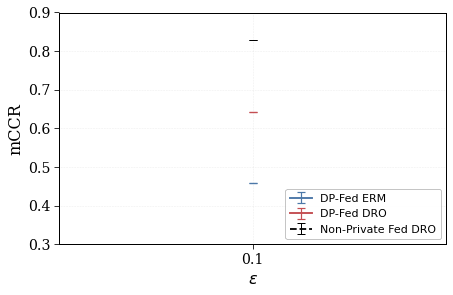

In [37]:
# CSV path
CSV_PATH = r"C:\Users\aphg2\OneDrive\Documents\MATLAB\Examples\R2025b\predmaint\MultiClassFaultDetectionUsingSimDataExample\ML_dataset_features_20260125_121332.csv"
# ---------------- experiment settings (simulation) ----------------
eps_list = [0.1]
seeds = [0]

G = 4
num_rounds = 50
perc_train = 0.8
perc_test  = 0.2
perc_wrong_y = 0.15
perc_class_per_client = 0
client_sample_props = [0.25, 0.25, 0.25, 0.25]
num_classes = 4

# privacy + DRO constants
DELTA_DP = 1e-3
DRO_AMBIG_EPS = 1e-2
#1e-6 returns DP DRO - 0.796 and NP DRO .804 and ERM - 0.747
#1e-5 returns DP DRO - 0.805 , NP DRO - 0.804, ERM - 0.753
#1e-4 returns DP DRO - 0.806 , NP DRO - 0.804 , ERM - 0.753
#1e-3 returns DP DRO - 0.810 , NP DRO - 0.809 , ERM - 0.753 
#1e-2 returns DP DRO - 0.805  , NP DRO -0.808 , ERM - 0.753
#1e-1 returns DP DRO - 0.805 , NP DRO - 0.799, ERM - 

feature_dim_sim = 14

# model hyperparams
RHO_ERM = 0.8
RHO_DRO = 0.8
# 0.2 returns DP DRO - 0.843  and NP DRO - 0.787 and ERM - 0.746 
# 0.5 returns DP DRO - 0.805  , NP DRO -0.808 , ERM - 0.753
# 0.7 returns DP DRO -0.790   , NP DRO  0.832 , ERM - 0.758
# 0.8 returns DP DRO - 0.805 and NP DRO 0.836 and ERM - 0.762
# 0.9 returns DP DRO - 0.790 and NP DRO 0.831  and ERM 0.766

CW      = 2
#Cw 0.1 DP DRO - 0.806 and NP DRO 0.831  and ERM 0.763
#Cw 0.5 DP DRO - 0.837 and NP DRO  0.831 and ERM 0.767
#Cw 1 DP DRO - 0.827 and NP DRO 0.831  and ERM 0.769
#Cw 5 DP DRO - 0.790 and NP DRO 0.831  and ERM 0.766
#Cw 10 DP DRO -0.782  and NP DRO 0.831 and ERM 0.757

CLIP_L_SIM = 1
L_LIP   = 1
LAMBDA_REG = 1e-6
KAPPA   = 0.5
TAU = 0
#Kappa 0.1 DP DRO 0.416  and NP DRO 0.770 and ERM 0.0.766
#Kappa 0.5 DP DRO 0.790  and NP DRO 0.831 and ERM 0.0.766
#kappa 0.8 DP DRO 0.810  and NP DRO 0.825 and ERM 0.0.766


PNORM   = float('Inf')
feature_scaling = "minmax"

# Bertsekas penalty parameters
GAMMA_PEN = 0.1
TAU_INIT  = 0.0

# lambda-block stepsize constants Assuming upperbound on the norm of M is 2
CLAMBDA = 2  
S_LAM   = KAPPA 
V_LAM   = 1     
C_M = GAMMA_PEN * (4)

results_csv = run_privacy_utility_experiment(
    eps_list=eps_list,
    seeds=seeds,
    num_classes=num_classes,
    train_dp_erm=train_dp_erm_csv,
    train_dp_dro=train_dp_dro_csv,
    train_np_dro=train_np_dro_csv
)

plot_privacy_utility(results_csv)

In [39]:
import os

for root, dirs, files in os.walk(os.getcwd()):
    for file in files:
        if file.endswith(".ipynb"):
            print(os.path.join(root, file))

C:\Users\aphg2\# of Classes vs Runtime per Round Experiment 5 Fed Multi DP DRO -Copy1.ipynb
C:\Users\aphg2\# of Classes vs Runtime per Round Experiment 5 Fed Multi DP DRO .ipynb
C:\Users\aphg2\Baseline - Differentially Private Fed DRO SVM  .ipynb
C:\Users\aphg2\BCW_Data.ipynb
C:\Users\aphg2\Delta vs mCCR DP Fed DRO Experiment 3.ipynb
C:\Users\aphg2\DR_LR_Sanity_Check.ipynb
C:\Users\aphg2\DR_LR_Sanity_Check_Banknote.ipynb
C:\Users\aphg2\Epsilon vs mCCR DP Fed DRO Experiment 1-Copy1.ipynb
C:\Users\aphg2\Epsilon vs mCCR DP Fed DRO Experiment 1.ipynb
C:\Users\aphg2\Epsilon vs mCCR for Diff Delta Fed Multi DP DRO Experiment 6.ipynb
C:\Users\aphg2\Experiments_DR-SVM.ipynb
C:\Users\aphg2\F1 Score Table for Fed DP Multi DRO Experiment 7-Copy2.ipynb
C:\Users\aphg2\F1 Score Table for Fed DP Multi DRO Experiment 7-Last Updated-Copy1.ipynb
C:\Users\aphg2\F1 Score Table for Fed DP Multi DRO Experiment 7-Last Updated.ipynb
C:\Users\aphg2\F1 Score Table for Fed DP Multi DRO Experiment 7.ipynb
C:\User

C:\Users\aphg2\anaconda3\Lib\site-packages\notebook\bundler\tests\resources\empty.ipynb
C:\Users\aphg2\anaconda3\pkgs\conda-4.8.3-py38_0\info\test\tests\conda_env\support\notebook.ipynb
C:\Users\aphg2\anaconda3\pkgs\conda-4.8.3-py38_0\info\test\tests\conda_env\support\notebook_with_env.ipynb
C:\Users\aphg2\anaconda3\pkgs\matplotlib-base-3.2.2-py38h64f37c6_0\Lib\site-packages\matplotlib\backends\web_backend\nbagg_uat.ipynb
C:\Users\aphg2\anaconda3\pkgs\nbconvert-5.6.1-py38_0\info\test\nbconvert\tests\files\notebook1.ipynb
C:\Users\aphg2\anaconda3\pkgs\nbconvert-5.6.1-py38_0\Lib\site-packages\nbconvert\exporters\tests\files\attachment.ipynb
C:\Users\aphg2\anaconda3\pkgs\nbconvert-5.6.1-py38_0\Lib\site-packages\nbconvert\exporters\tests\files\notebook2.ipynb
C:\Users\aphg2\anaconda3\pkgs\nbconvert-5.6.1-py38_0\Lib\site-packages\nbconvert\exporters\tests\files\pngmetadata.ipynb
C:\Users\aphg2\anaconda3\pkgs\nbconvert-5.6.1-py38_0\Lib\site-packages\nbconvert\exporters\tests\files\prompt_num